# Regressão 01 - tarefa 03 - transformações em X e Y

Carregue os pacotes necessários e a base de gorjetas.

### I. Modelo no valor da gorjeta

1. Crie a matriz de design (e a matriz y) utilizando o Patsy, para um modelo em ```tip```, explicada por ```sex, smoker, diner e net_bill```.  
2. Remova as variáveis não significantes.  
3. observe o gráfico de resíduos em função de ```net_bill```  
4. teste transformar ```net_bill``` no log e um polinômio. Escolha o melhor modelo.

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.324
Method:                 Least Squares   F-statistic:                     30.13
Date:                Mon, 18 May 2026   Prob (F-statistic):           2.64e-20
Time:                        09:36:24   Log-Likelihood:                -375.13
No. Observations:                 244   AIC:                             760.3
Df Residuals:                     239   BIC:                             777.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          1.1999      0.242      4.

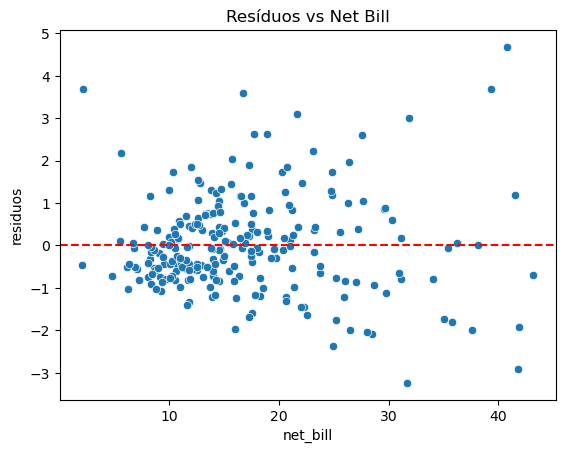

R² Polinomial: 0.3346


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

tips = sns.load_dataset("tips")
tips['net_bill'] = tips['total_bill'] - tips['tip']
tips['tip_pct'] = tips['tip'] / tips['net_bill']

# 1. Ajuste do modelo com Patsy (o statsmodels já usa Patsy por baixo das fórmulas)
# Variáveis: sex, smoker, time (no lugar de diner) e net_bill
reg_tip = smf.ols('tip ~ sex + smoker + time + net_bill', data=tips).fit()

# 2. Removendo não significantes (olhe o P>|t| no summary)
# Geralmente sex e smoker não são significantes. Se for o caso, mantenha apenas net_bill e time.
print(reg_tip.summary())

# 3. Gráfico de resíduos
tips['residuos'] = reg_tip.resid
sns.scatterplot(x='net_bill', y='residuos', data=tips)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Resíduos vs Net Bill')
plt.show()

# 4. Teste transformar net_bill (exemplo polinômio)
reg_tip_poly = smf.ols('tip ~ time + net_bill + np.power(net_bill, 2)', data=tips).fit()
print(f"R² Polinomial: {reg_tip_poly.rsquared:.4f}")

### II. Modelo no valor do percentual da gorjeta

1. Crie a matriz de design (e a matriz y) utilizando o Patsy, para um modelo no log de ```tip```, explicado por ```sex, smoker, diner e net_bill```.
2. Remova as variáveis não significantes.
3. Observe o gráfico de resíduos em função de ```net_bill```
4. Teste transformar ```net_bill``` no log e um polinômio. Escolha o melhor modelo.
5. Do modelo final deste item, calcule o $R^2$ na escala de ```tip``` (sem o log). Compare com o modelo do item 1. Qual tem melhor coeficiente de determinação?

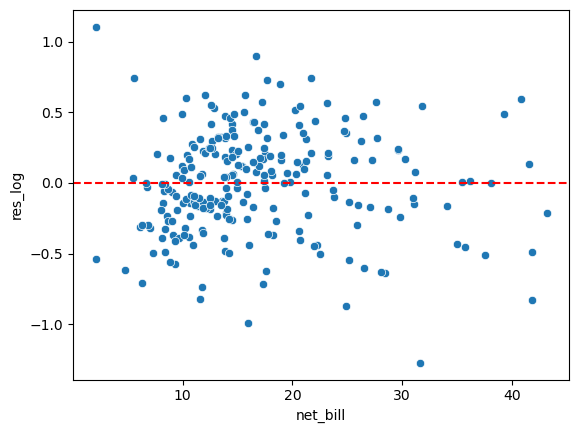

R² do Modelo Log na escala de tip: 0.3245


In [3]:
# 1. Modelo no log de tip
reg_log_tip = smf.ols('np.log(tip) ~ sex + smoker + time + net_bill', data=tips).fit()

# 3. Gráfico de resíduos (escala log)
tips['res_log'] = reg_log_tip.resid
sns.scatterplot(x='net_bill', y='res_log', data=tips)
plt.axhline(y=0, color='r', linestyle='--')
plt.show()

# 5. Cálculo do R² na escala original (tip)
tips['pred_tip_final'] = np.exp(reg_log_tip.fittedvalues)
r2_escala_original = tips[['tip', 'pred_tip_final']].corr().iloc[0,1]**2
print(f"R² do Modelo Log na escala de tip: {r2_escala_original:.4f}")

### III. Previsão de renda

Vamos trabalhar a base que você vai usar no projeto do final deste ciclo.

Carregue a base ```previsao_de_renda.csv```.

|variavel|descrição|
|-|-|
|data_ref                | Data de referência de coleta das variáveis |
|index                   | Código de identificação do cliente|
|sexo                    | Sexo do cliente|
|posse_de_veiculo        | Indica se o cliente possui veículo|
|posse_de_imovel         | Indica se o cliente possui imóvel|
|qtd_filhos              | Quantidade de filhos do cliente|
|tipo_renda              | Tipo de renda do cliente|
|educacao                | Grau de instrução do cliente|
|estado_civil            | Estado civil do cliente|
|tipo_residencia         | Tipo de residência do cliente (própria, alugada etc)|
|idade                   | Idade do cliente|
|tempo_emprego           | Tempo no emprego atual|
|qt_pessoas_residencia   | Quantidade de pessoas que moram na residência|
|renda                   | Renda em reais|

1. Ajuste um modelo de regressão linear simples para explicar ```renda``` como variável resposta, por ```tempo_emprego``` como variável explicativa. Observe que há muitas observações nessa tabela. Utilize os recursos que achar necessário.
2. Faça uma análise de resíduos. Com os recursos vistos neste módulo, como você melhoraria esta regressão?
3. Ajuste um modelo de regressão linear múltipla para explicar ```renda``` (ou uma transformação de ```renda```) de acordo com as demais variáveis.
4. Remova as variáveis não significantes e ajuste novamente o modelo. Interprete os parâmetros
5. Faça uma análise de resíduos. Avalie a qualidade do ajuste.

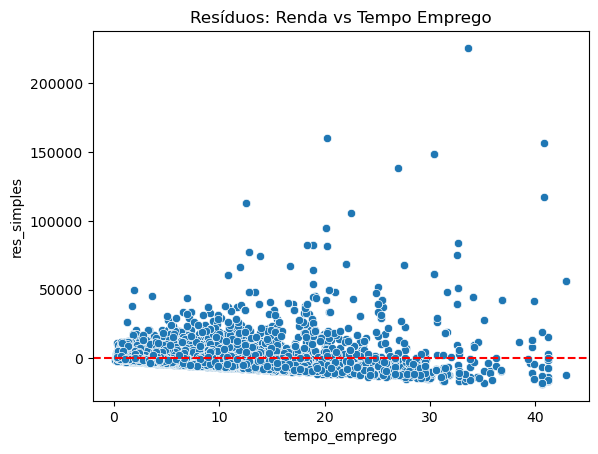

                            OLS Regression Results                            
Dep. Variable:          np.log(renda)   R-squared:                       0.346
Model:                            OLS   Adj. R-squared:                  0.346
Method:                 Least Squares   F-statistic:                     1315.
Date:                Mon, 18 May 2026   Prob (F-statistic):               0.00
Time:                        09:40:06   Log-Likelihood:                -13676.
No. Observations:               12427   AIC:                         2.736e+04
Df Residuals:                   12421   BIC:                         2.741e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

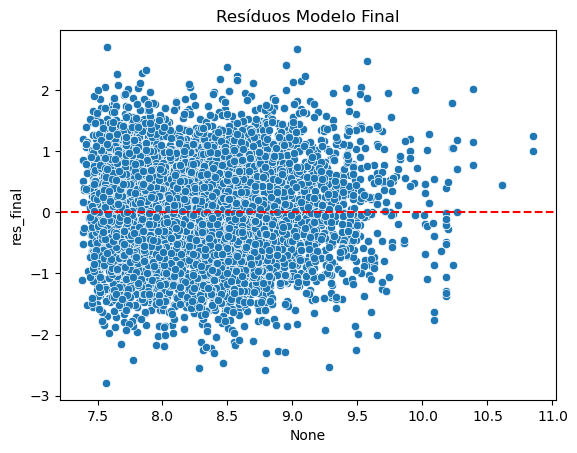

In [5]:
# Carregando a nova base
renda = pd.read_csv('Profissão Cientista de Dados M12 - previsao_de_renda.csv')

# 1. Regressão simples: renda ~ tempo_emprego
reg_renda_simples = smf.ols('renda ~ tempo_emprego', data=renda).fit()

# 2. Análise de resíduos
renda['res_simples'] = reg_renda_simples.resid
sns.scatterplot(x='tempo_emprego', y='res_simples', data=renda)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Resíduos: Renda vs Tempo Emprego')
plt.show()

# 3 e 4. Regressão múltipla com todas as variáveis (removendo não significantes)
# Dica: use o log(renda) para melhorar o ajuste, pois renda costuma ser assimétrica
reg_renda_mult = smf.ols('np.log(renda) ~ sexo + posse_de_veiculo + posse_de_imovel + idade + tempo_emprego', data=renda).fit()
print(reg_renda_mult.summary())

# 5. Análise de resíduos final
renda['res_final'] = reg_renda_mult.resid
sns.scatterplot(x=reg_renda_mult.fittedvalues, y='res_final', data=renda)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Resíduos Modelo Final')
plt.show()